In [1]:
import os, sys
import numpy as np
module_path = os.path.abspath(os.path.join('..'))
sys.path.append(module_path+"\\KAN_variants")
from ChebyKANLayer import ChebyKAN
from ChebyKANLayer import ChebyKANLayer

module_path = os.path.abspath(os.path.join('..'))
sys.path.append(module_path+"\\code")
from myKANODE import KANODE

In [2]:
def pred_prey_deriv(X, t, alpha, beta, delta, gamma):
    x=X[0]
    y=X[1]
    dxdt = alpha*x-beta*x*y
    dydt = delta*x*y-gamma*y
    dXdt=[dxdt, dydt]
    return dXdt
X0 = [0.1, 1.5]
Params = [1.5, 1, 2, 1]

In [3]:
models = [ChebyKAN(np.append(2, np.append(np.ones([layerCount], dtype=int) * layerSize, 2)), 4) for layerSize in range(5, 10, 2) for layerCount in range(1,5)]
kanODEs = [KANODE(model, pred_prey_deriv, X0, Params, 20, 7.5, 150) for model in models]

100%|██████████| 800/800 [14:57<00:00,  1.12s/it]


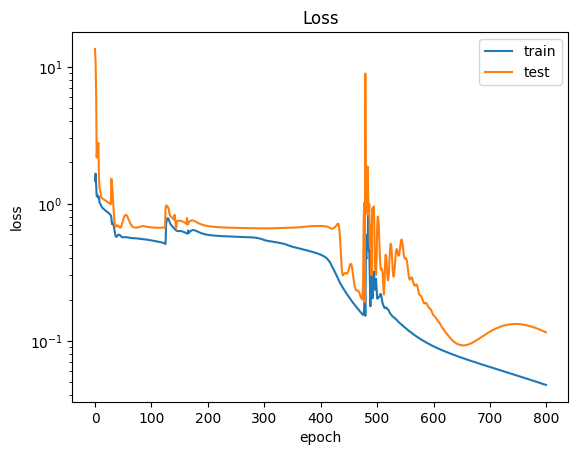

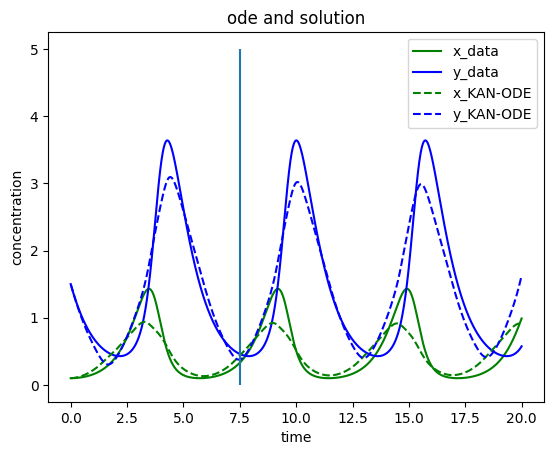

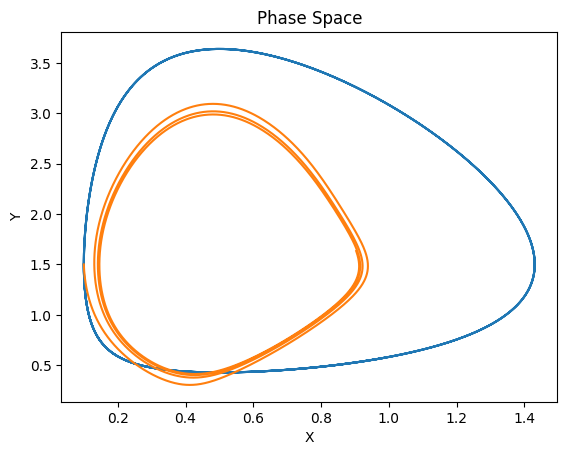

100%|██████████| 800/800 [19:10<00:00,  1.44s/it]


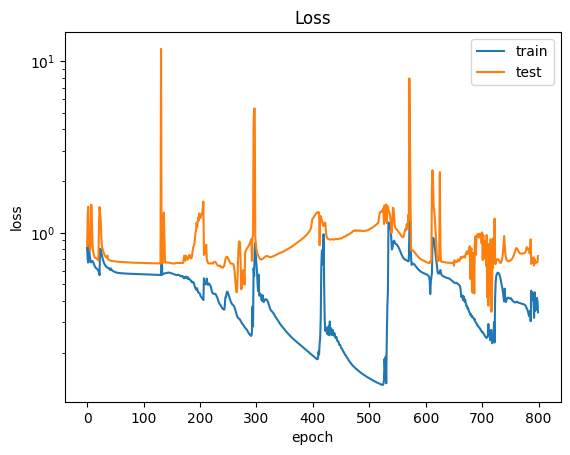

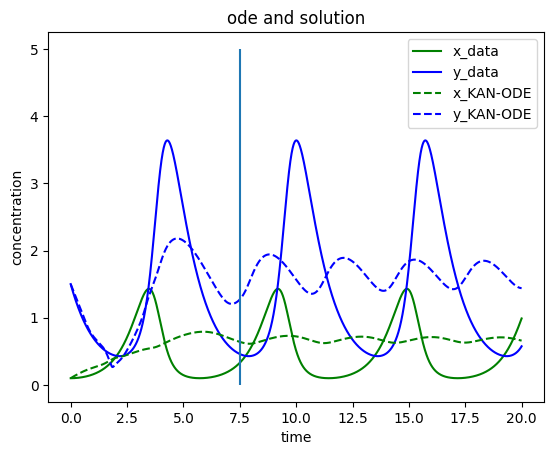

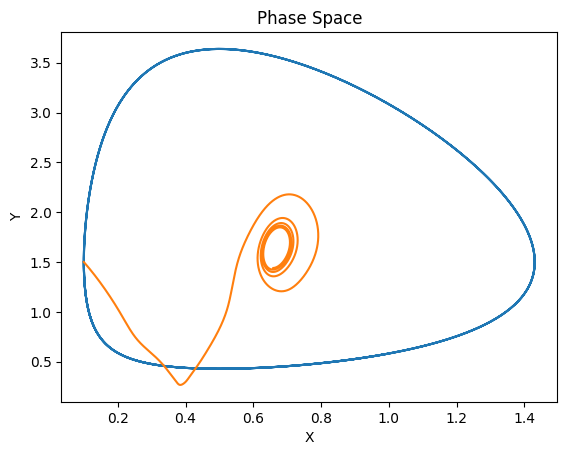

100%|██████████| 800/800 [24:20<00:00,  1.83s/it]  


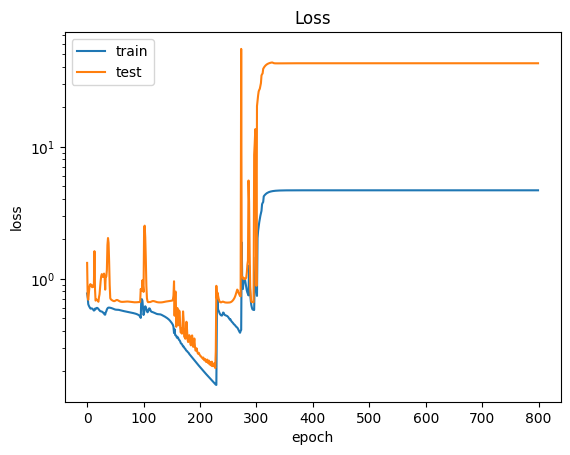

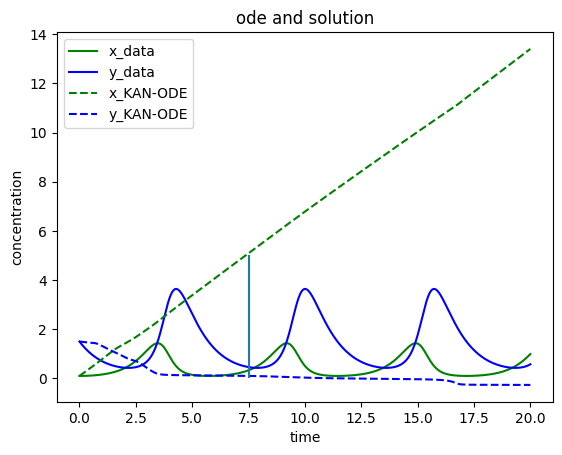

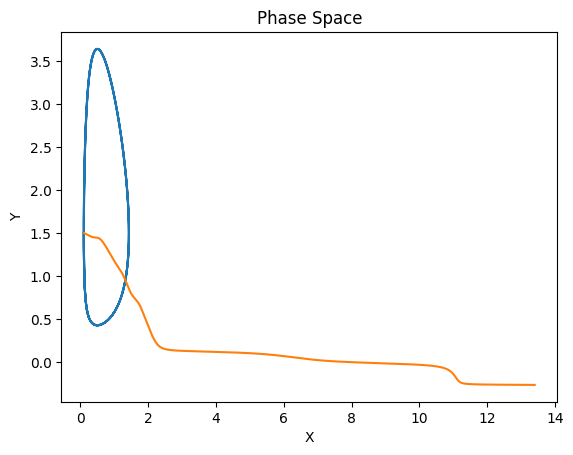

 20%|█▉        | 156/800 [20:07<1:23:04,  7.74s/it]


AssertionError: underflow in dt 0.0

In [4]:
for kanODE in kanODEs:
    saveDirectory = os.path.join(module_path, "savedModels", "structureSweep1", f"layerSize-{kanODE.model.layers[0].outdim}_layerCount-{len(kanODE.model.layers)-1}")
    os.makedirs(saveDirectory)
    kanODE.train(-1, maxEpochs=800, saveDirectory=saveDirectory, saveCooldown=100)
    _, solution = kanODE.test()
    kanODE.plotLoss("Loss")
    kanODE.plotODE("ode and solution", solution[:, 0, :])
    kanODE.plotPhaseSpace("Phase Space", solution[:, 0, :])